# Telco Churn EDA
This notebook performs a concise exploratory data analysis for the Telco Customer Churn dataset.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = Path('..') / 'data' / 'raw' / 'churn.csv'
df = pd.read_csv(DATA_PATH)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset Shape and Types
We inspect structure and datatypes to identify cleaning requirements.

In [6]:
print(f'Shape: {df.shape}')
df.info()

Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Missing Values
The `TotalCharges` field in this dataset may contain blank strings that need numeric coercion.

In [8]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts[missing_counts > 0]

Series([], dtype: int64)

In [9]:
blank_total_charges = (df['TotalCharges'].astype(str).str.strip() == '').sum()
print(f'Blank TotalCharges rows: {blank_total_charges}')

Blank TotalCharges rows: 11


## Target Distribution
Churn class balance helps interpret accuracy and F1 results during model training.

In [7]:
churn_counts = df['Churn'].value_counts()
churn_counts

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [ ]:
plt.figure(figsize=(5, 4))
churn_counts.plot(kind='bar', color=['#2a9d8f', '#e76f51'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Tenure and Monthly Charges by Churn
Simple visual checks show whether churn behavior differs by service duration and spending.

In [10]:
eda_df = df.copy()
eda_df['TotalCharges'] = pd.to_numeric(eda_df['TotalCharges'], errors='coerce')
eda_df = eda_df.dropna(subset=['TotalCharges'])

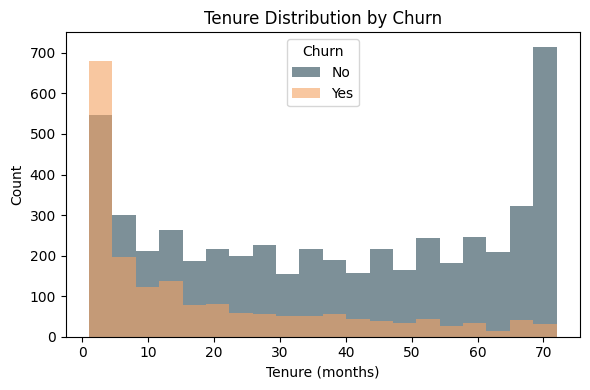

In [11]:
plt.figure(figsize=(6, 4))
for label, color in [('No', '#264653'), ('Yes', '#f4a261')]:
    subset = eda_df.loc[eda_df['Churn'] == label, 'tenure']
    plt.hist(subset, bins=20, alpha=0.6, label=label, color=color)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

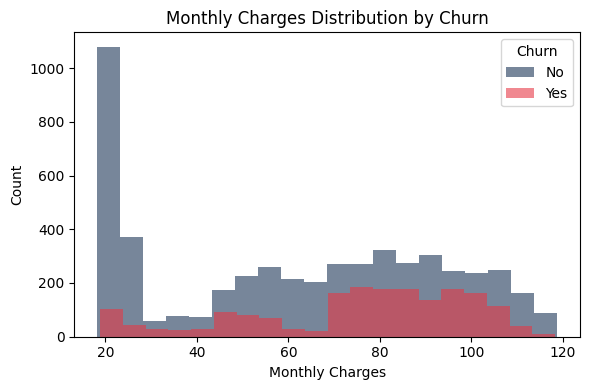

In [12]:
plt.figure(figsize=(6, 4))
for label, color in [('No', '#1d3557'), ('Yes', '#e63946')]:
    subset = eda_df.loc[eda_df['Churn'] == label, 'MonthlyCharges']
    plt.hist(subset, bins=20, alpha=0.6, label=label, color=color)
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges')
plt.ylabel('Count')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

## Quick Insights
- The dataset has mixed numeric and categorical variables, supporting a pipeline-based preprocessing strategy.
- `TotalCharges` requires coercion to numeric before modeling.
- Churn appears meaningfully related to customer tenure and charge patterns.